# Data Loading example

In [6]:
import pandas as pd

from kielmat.utils.kielmat_dataclass import KielMATRecording # Import the KielMATRecording class
from kielmat.modules.gsd import ParaschivIonescuGaitSequenceDetection # Import the Gait Sequence Detection m

# Set the url for the raw data on GH
file_url = 'https://raw.githubusercontent.com/neurogeriatricskiel/KielMAT/main/examples/data/ExampleAccelDataRaw.csv'

# read the csv data from the url
acc_data = pd.read_csv(file_url)

# specifiy the sampling rate
fs = 100 # Hz

n_channels = acc_data.shape[1]
n_samples = acc_data.shape[0]

# check how many minutes of data we have
n_minutes = n_samples/fs/60
print(f"Minutes of data: {n_minutes:.2f}")



Minutes of data: 18.33


In [9]:
# construct the channel information

tracked_point = "lowerBack"

n_channels = acc_data.shape[1] # second dimension of the data represents the number of channels

col_names = [
    f"{tracked_point}_{s}_{x}"
    for s in ["ACCEL"]
    for x in ["x", "y", "z"]
]

# Make the channel dictionary following the BIDS naming conventions
channels_dict = {
    "name": col_names,
    "component": ["x", "y", "z"] * (n_channels // 3),
    "type": ["ACCEL"] * (n_channels),
    "tracked_point": [tracked_point] * n_channels,
    "units": ["m/s^2"] * n_channels,
    "sampling_frequency": [fs] * n_channels,
}

recording =  KielMATRecording(
    data={"imu": acc_data}, channels={"lb_imu": pd.DataFrame(channels_dict)}
)

print(recording.channels)

{'lb_imu':                 name component   type tracked_point  units  sampling_frequency
0  lowerBack_ACCEL_x         x  ACCEL     lowerBack  m/s^2                 100
1  lowerBack_ACCEL_y         y  ACCEL     lowerBack  m/s^2                 100
2  lowerBack_ACCEL_z         z  ACCEL     lowerBack  m/s^2                 100}


20 gait sequence(s) detected.


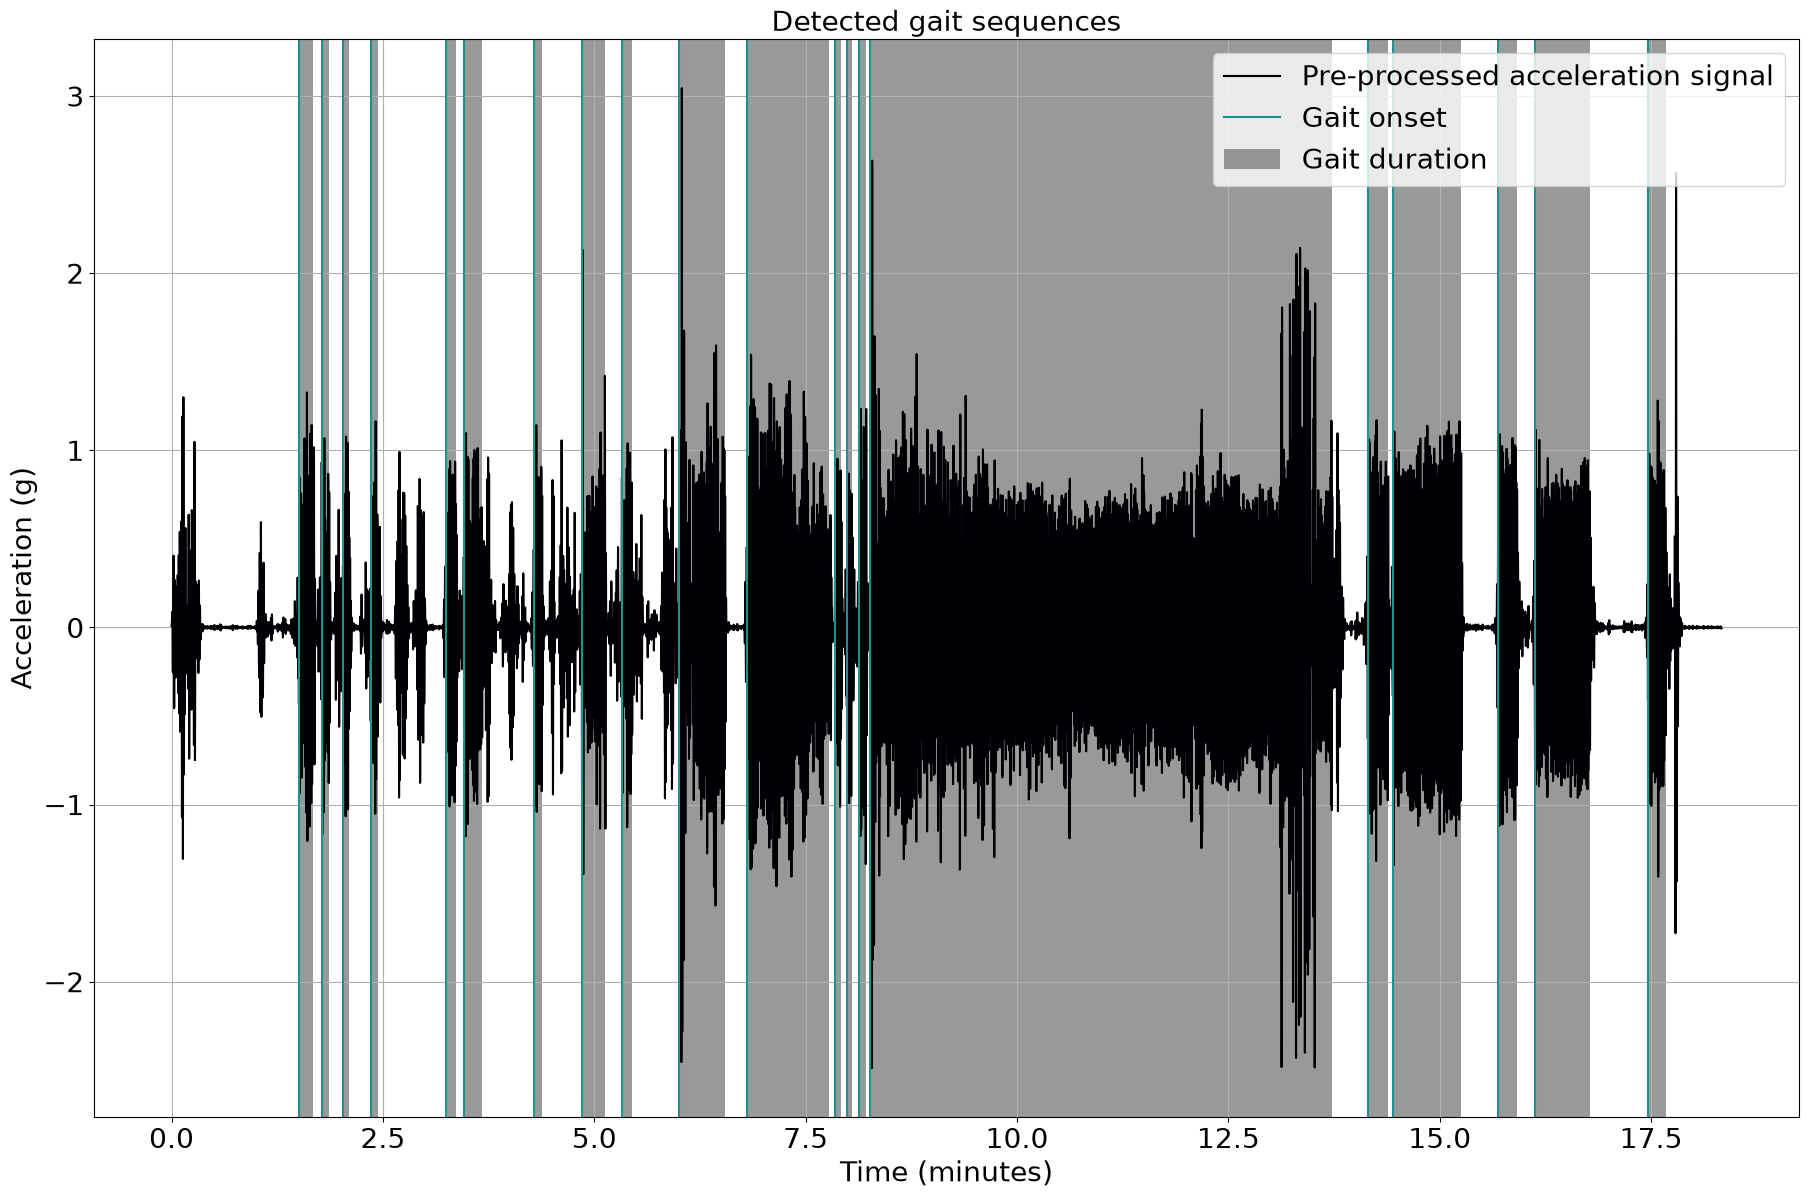

{'lowerBack':        onset  duration     event_type tracking_system
0     90.175    10.400  gait sequence            None
1    106.450     5.225  gait sequence            None
2    121.750     4.250  gait sequence            None
3    141.275     5.525  gait sequence            None
4    195.025     7.100  gait sequence            None
5    207.850    12.325  gait sequence            None
6    256.925     5.900  gait sequence            None
7    291.175    16.650  gait sequence            None
8    319.450     7.100  gait sequence            None
9    360.350    32.375  gait sequence            None
10   408.125    58.650  gait sequence            None
11   470.975     4.275  gait sequence            None
12   479.150     3.600  gait sequence            None
13   488.100     4.650  gait sequence            None
14   495.875   327.350  gait sequence            None
15   848.875    14.300  gait sequence            None
16   867.025    47.975  gait sequence            None
17   940.975  

In [10]:
# Create an instance of the ParaschivIonescuGaitSequenceDetection class
gsd = ParaschivIonescuGaitSequenceDetection()

# Call the gait sequence detection using gsd.detect
gsd = gsd.detect(
    data=recording.data["imu"], sampling_freq_Hz=fs, plot_results=True, dt_data=None
)

# Gait sequences are stored in gait_sequences_ attribute of gsd
gait_sequences = gsd.gait_sequences_

# Add events to the recording as a dictionary including tracking system and events
gait_sequence_events = gait_sequences
recording.add_events(tracking_system=tracked_point, new_events=gait_sequence_events)

# Show events and their corresponding information
print(recording.events)

In [11]:
n_gs = len(recording.events["lowerBack"])
mean_dur = recording.events["lowerBack"]["duration"].mean()
print(f"Mean duration of gait {n_gs:.0f} sequences: {mean_dur:.2f} seconds")

# also check the longest gait sequence
max_dur = recording.events["lowerBack"]["duration"].max()
max_dur_onset = recording.events["lowerBack"]["onset"][recording.events["lowerBack"]["duration"].idxmax()]
print(f"Longest gait sequence: {max_dur:.2f} seconds starting at about {max_dur_onset/60:.2f} minutes into the recording.")


Mean duration of gait 20 sequences: 31.65 seconds
Longest gait sequence: 327.35 seconds starting at about 8.26 minutes into the recording.


# Dataset Loading Example

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from kielmat.datasets import mobilised

# load the data
recording = mobilised.load_recording() # Broken

c:\Users\theil\Documents\0_summer2026\KielMAT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BadZipFile: File is not a zip file

In [ ]:
print(2)

# Events in Dataclass

In [8]:
from kielmat.datasets import mobilised
from kielmat.modules.gsd import ParaschivIonescuGaitSequenceDetection

# load the data from mobilised dataset
recordingLoaded = mobilised.load_recording()

# specify which tracking system you want to use
tracking_sys = 'SU'

In [11]:
recording = recordingLoaded

# Load lower back acceleration data
acceleration_data = recording.data[tracking_sys][
    ["LowerBack_ACCEL_x", "LowerBack_ACCEL_y", "LowerBack_ACCEL_z"]
]

# Get the corresponding sampling frequency directly from the recording
sampling_frequency = recording.channels[tracking_sys][
    recording.channels[tracking_sys]["name"] == "LowerBack_ACCEL_x"
]["sampling_frequency"].values[0]
print(f"Sampling frequency: {sampling_frequency} Hz")

Sampling frequency: 100.0 Hz


In [12]:
# Create an instance of the ParaschivIonescuGaitSequenceDetection class
gsd = ParaschivIonescuGaitSequenceDetection()

# Call the gait sequence detection using gsd.detect to detect gait sequences
gsd = gsd.detect(
    data=acceleration_data, sampling_freq_Hz=sampling_frequency, plot_results=False
)

36 gait sequence(s) detected.


In [13]:
# Add events to the recording as a dictionary including tracking system and events
gait_sequence_events = gsd.gait_sequences_
recording.add_events(tracking_system=tracking_sys, new_events=gait_sequence_events)
print(f"events: {recording.events}")

events: {'SU':        onset  duration     event_type tracking_system
0     22.650    17.075  gait sequence            None
1     49.150     7.475  gait sequence            None
2     97.025   120.400  gait sequence            None
3    229.550     9.225  gait sequence            None
4    247.900    29.075  gait sequence            None
5    296.225   189.600  gait sequence            None
6    490.300    25.575  gait sequence            None
7    562.925    15.075  gait sequence            None
8    581.900    18.875  gait sequence            None
9    607.050    56.600  gait sequence            None
10   667.325   101.900  gait sequence            None
11   784.500    42.775  gait sequence            None
12   835.675   174.675  gait sequence            None
13  1034.900    42.050  gait sequence            None
14  1103.075    39.475  gait sequence            None
15  1153.750    13.125  gait sequence            None
16  1184.900     5.775  gait sequence            None
17  1219.175 

# Gait Sequence Detection

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from kielmat.datasets import mobilised
from kielmat.modules.gsd import ParaschivIonescuGaitSequenceDetection
from kielmat.config import cfg_colors

In [15]:
# Set the dataset path
dataset_path = Path(os.getcwd()) / "_mobilised"

# Fetch and load the dataset
mobilised.fetch_dataset(dataset_path=dataset_path)

# In this example, we use "SU" as tracking_system and "LowerBack" as tracked points.
tracking_sys = "SU"
tracked_points = {tracking_sys: ["LowerBack"]}

# The 'mobilised.load_recording' function is used to load the data from the specified file_path
recording = mobilised.load_recording(
    cohort="PFF",  # Choose the cohort
    file_name="data.mat", 
    dataset_path=dataset_path)

# Load lower back acceleration data
accel_data = recording.data[tracking_sys][
    ["LowerBack_ACCEL_x", "LowerBack_ACCEL_y", "LowerBack_ACCEL_z"]
]

# Get the corresponding sampling frequency directly from the recording
sampling_frequency = recording.channels[tracking_sys][
    recording.channels[tracking_sys]["name"] == "LowerBack_ACCEL_x"
]["sampling_frequency"].values[0]

100%|######################################| 1.34G/1.34G [00:00<00:00, 445GB/s]


In [16]:
# Get the corresponding unit of the acceleration data
accel_unit = recording.channels[tracking_sys][
    recording.channels[tracking_sys]["name"].str.contains("ACCEL", case=False)
]["units"].iloc[0]

# Check unit of acceleration data
if accel_unit in ["m/s^2"]:
    pass  # No conversion needed
elif accel_unit in ["g", "G"]:
    # Convert acceleration data from "g" to "m/s^2"
    accel_data *= 9.81
    # Update unit of acceleration
    accel_unit = ["m/s^2"]

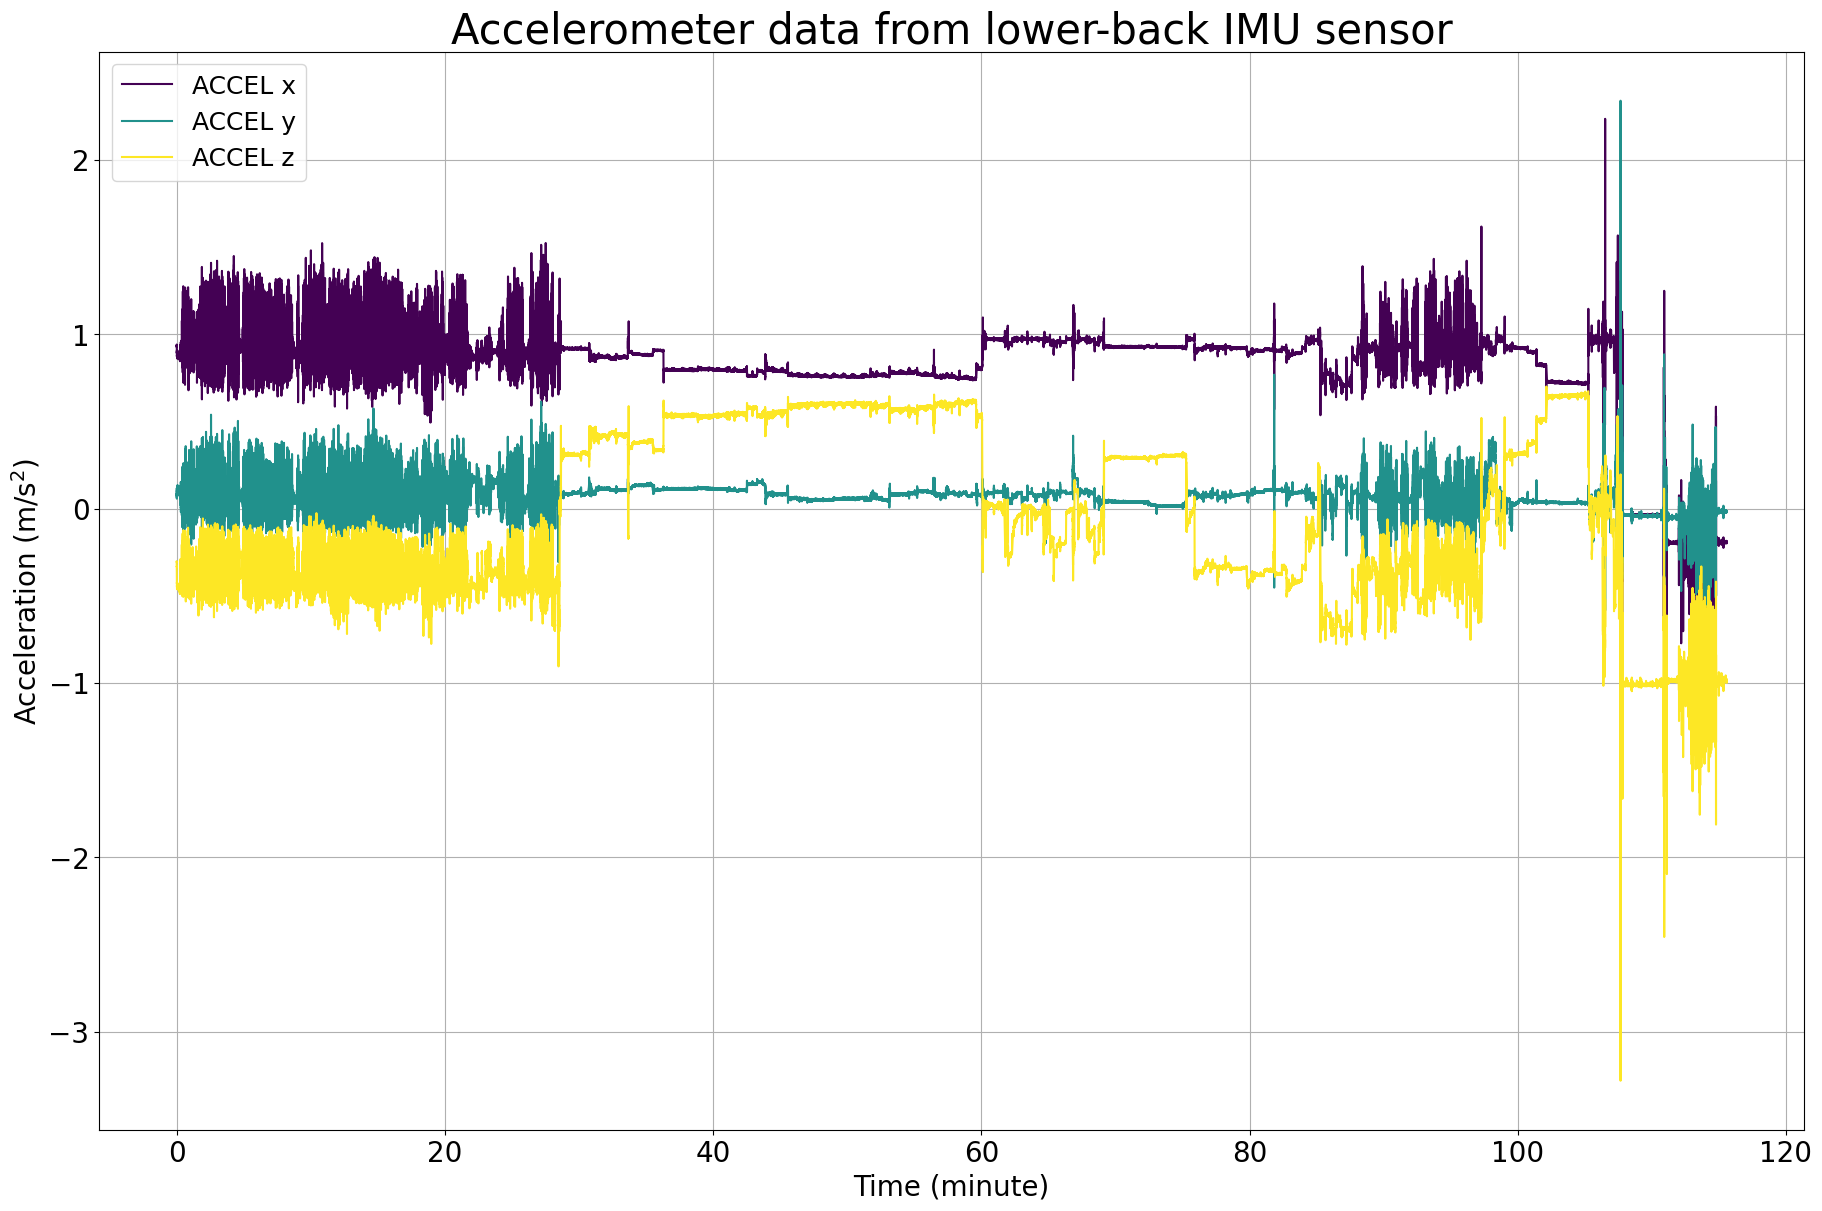

In [18]:
# Calculate the time values in minutes
# The 'time_in_minute' array represents time values in minutes, computed based on the length of 'acceleration_data' and 'sampling_frequency'.
time_in_minute = np.arange(len(acceleration_data)) / (60 * sampling_frequency)

# Create a figure with a specified size
plt.figure(figsize=(22, 14))

# Get colors for raw
colors = cfg_colors["raw"]

# A loop is used to plot data for each accelerometer axis, applying different colors from the color map.
for i in range(3):
    plt.plot(
        time_in_minute,
        acceleration_data[f"LowerBack_ACCEL_{chr(120 + i)}"],
        color=colors[i],
        label=f"ACCEL {'xyz'[i]}",
    )

# Add labels and legends
plt.xlabel("Time (minute)", fontsize=20)
plt.ylabel(f"Acceleration (m/s$^{2}$)", fontsize=20)
plt.legend(fontsize=18)

# Add a title with a specified font size
plt.title(
    "Accelerometer data from lower-back IMU sensor",
    fontsize=30,
)

# Customize tick font sizes
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Display a grid for reference
plt.grid(visible=None, which="both", axis="both")

# Show the plot
plt.show()

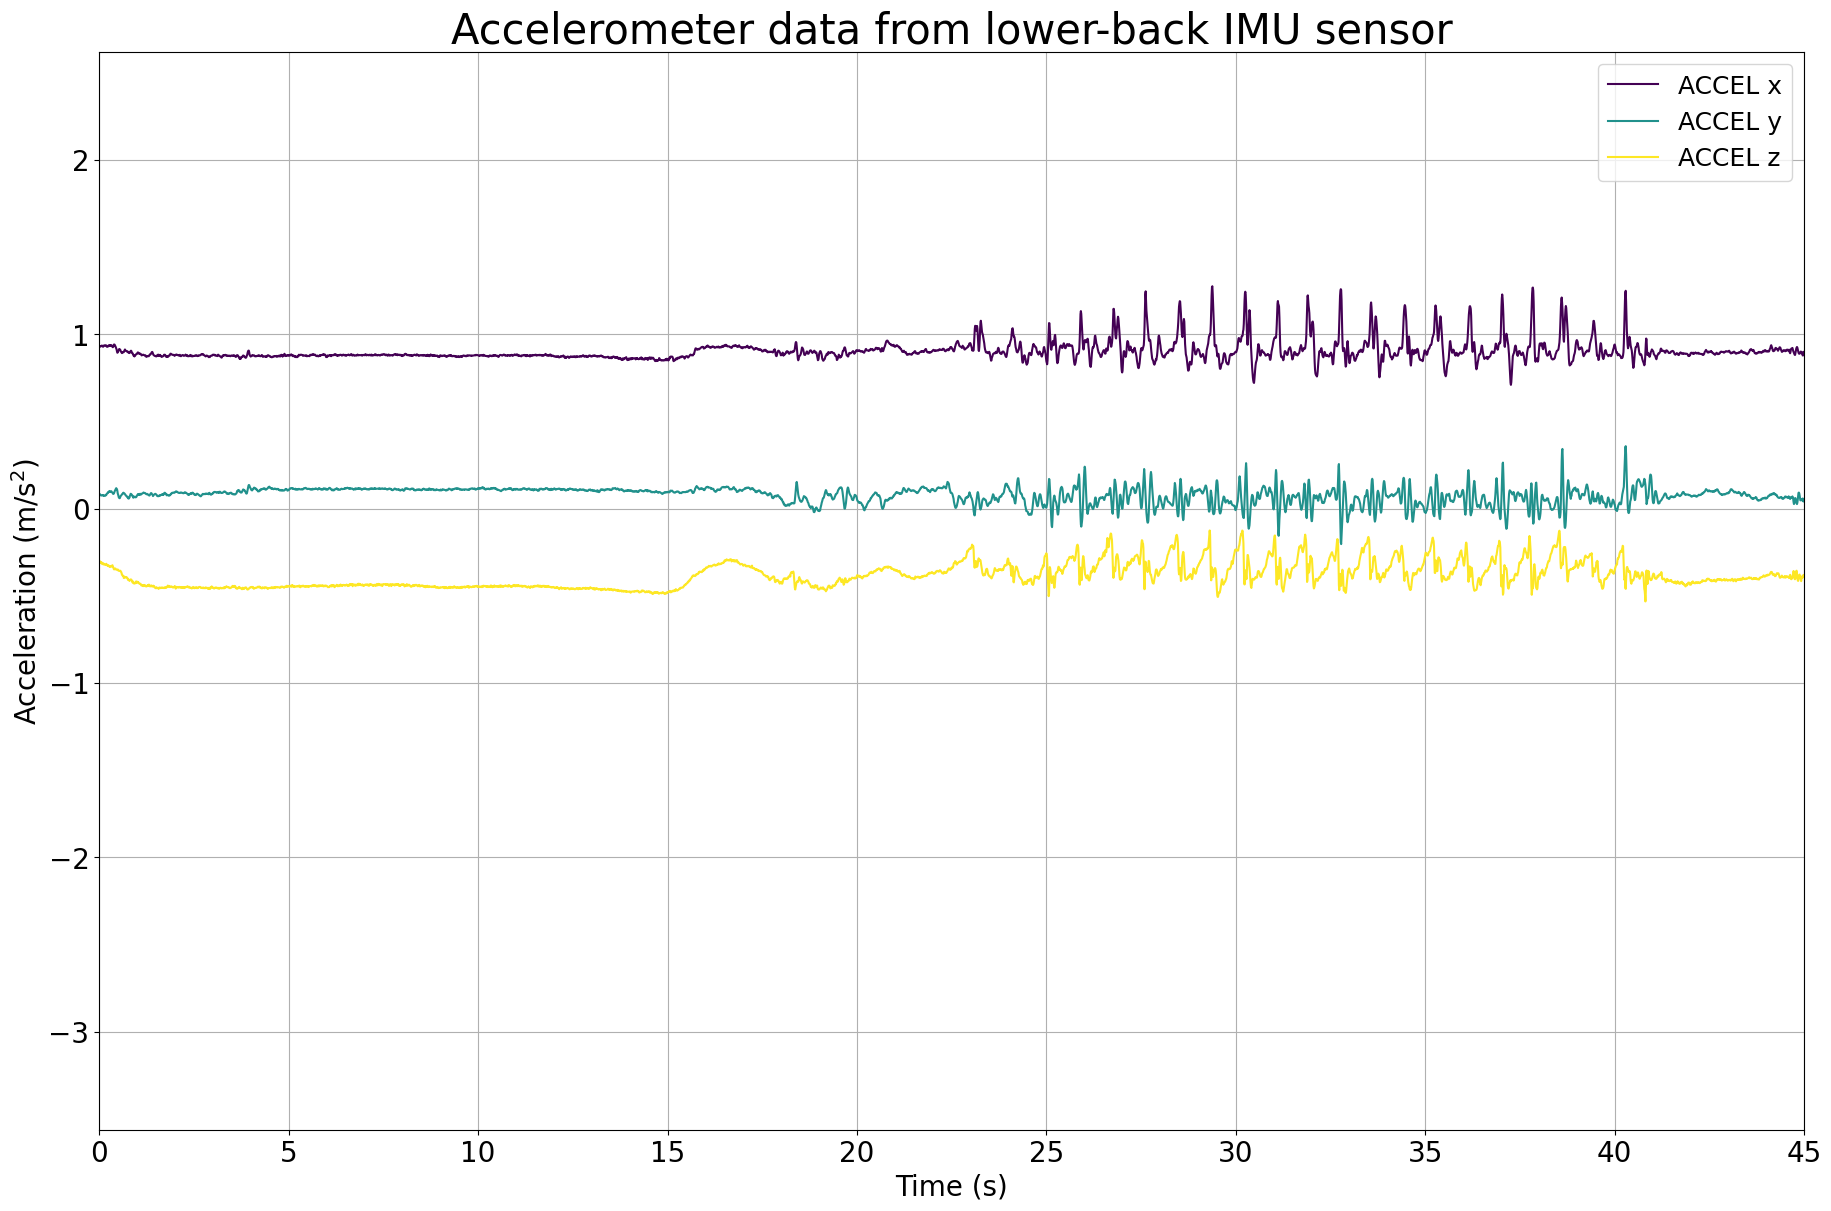

In [20]:
# Calculate the time values based on the length of the data
num_samples = len(acceleration_data)
time_seconds = np.arange(num_samples) / sampling_frequency

# Create a figure with the specified size
plt.figure(figsize=(22, 14))

# Plot acceleration data for each axis with time on the x-axis
for i in range(3):
    plt.plot(
        time_seconds,
        acceleration_data[f"LowerBack_ACCEL_{chr(120 + i)}"],
        color=colors[i],
        label=f"ACCEL {'xyz'[i]}",
    )

# Add labels and legends
plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Acceleration (m/s$^{2}$)", fontsize=20)
plt.legend(fontsize=18)

# Add a title
plt.title(
    "Accelerometer data from lower-back IMU sensor",
    fontsize=30,
)

# Customize font sizes
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Set x-axis and y-axis limits for a specific duration (in seconds) and acceleration range
plt.xlim(0, 45)

# Display a grid for reference
plt.grid(visible=None, which="both", axis="both")

# Show the plot
plt.show()

36 gait sequence(s) detected.


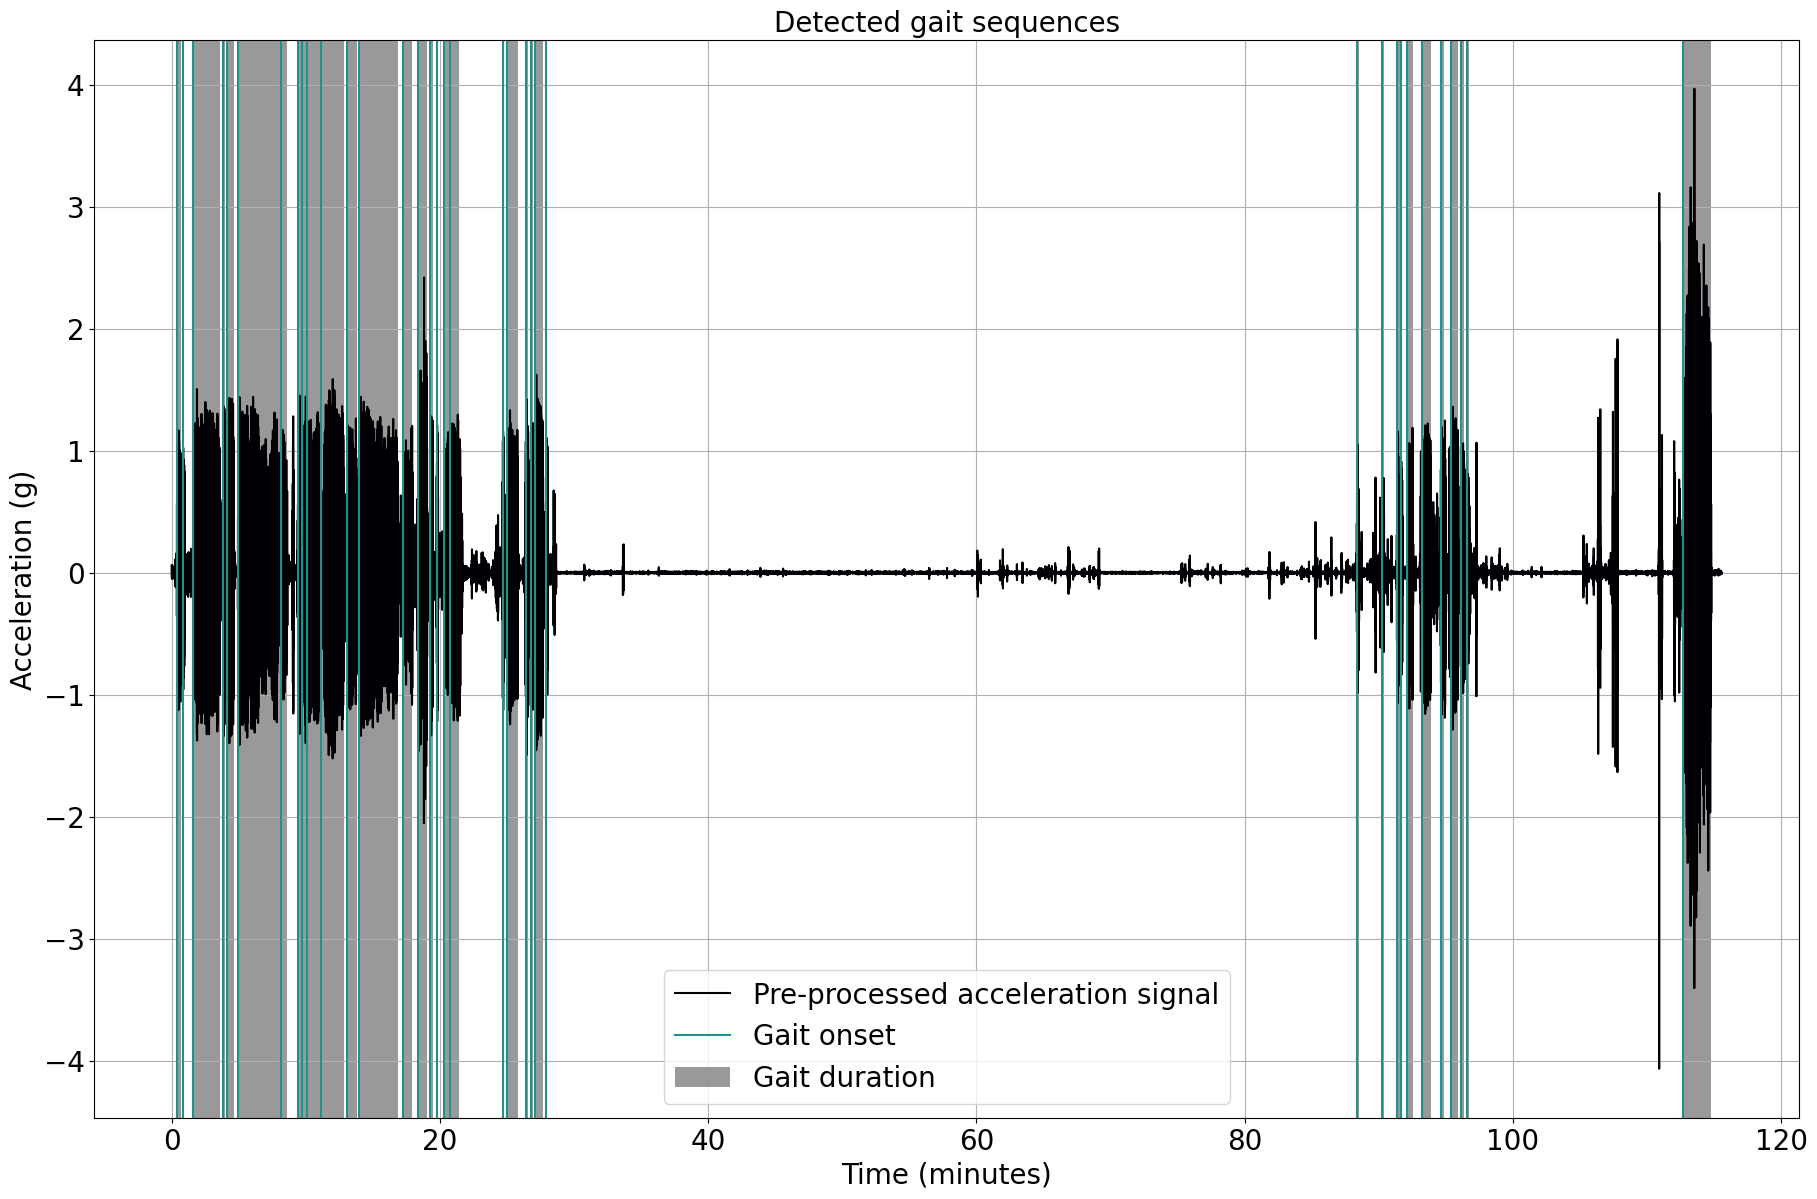

{'SU':        onset  duration     event_type tracking_system
0     22.650    17.075  gait sequence            None
1     49.150     7.475  gait sequence            None
2     97.025   120.400  gait sequence            None
3    229.550     9.225  gait sequence            None
4    247.900    29.075  gait sequence            None
5    296.225   189.600  gait sequence            None
6    490.300    25.575  gait sequence            None
7    562.925    15.075  gait sequence            None
8    581.900    18.875  gait sequence            None
9    607.050    56.600  gait sequence            None
10   667.325   101.900  gait sequence            None
11   784.500    42.775  gait sequence            None
12   835.675   174.675  gait sequence            None
13  1034.900    42.050  gait sequence            None
14  1103.075    39.475  gait sequence            None
15  1153.750    13.125  gait sequence            None
16  1184.900     5.775  gait sequence            None
17  1219.175    21.22

In [22]:
# Create an instance of the ParaschivIonescuGaitSequenceDetection class
gsd = ParaschivIonescuGaitSequenceDetection()

# Call the gait sequence detection using gsd.detect
gsd = gsd.detect(
    acceleration_data, sampling_freq_Hz=sampling_frequency, plot_results=True, dt_data=None
)

# Gait sequences are stored in gait_sequences_ attribute of gsd
gait_sequences = gsd.gait_sequences_

# Add events to the recording as a dictionary including tracking system and events
gait_sequence_events = gait_sequences
recording.add_events(tracking_system=tracking_sys, new_events=gait_sequence_events)

# Show events and their corresponding information
print(recording.events)

First gait sequence:
 onset                      22.65
duration                  17.075
event_type         gait sequence
tracking_system             None
Name: 0, dtype: object


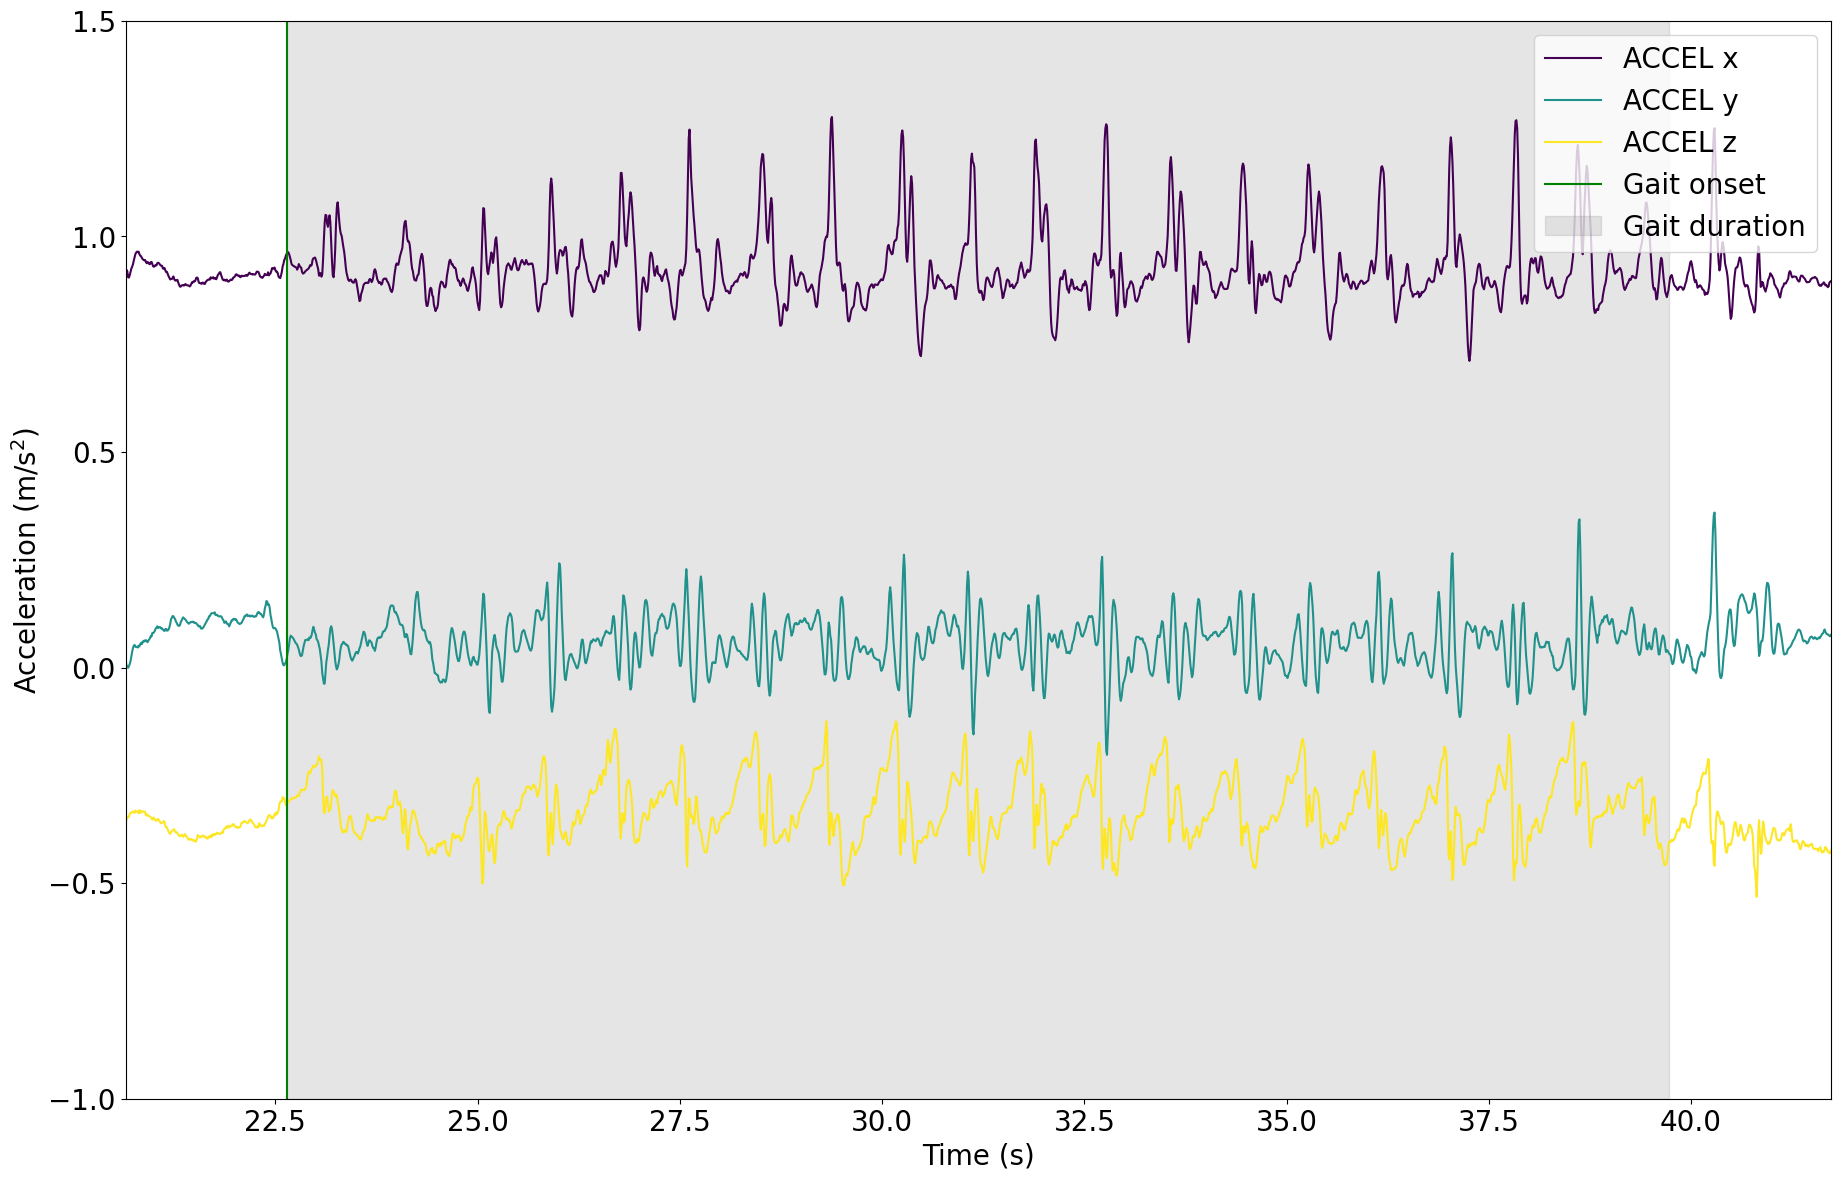

In [23]:
# Access and print first detected gait sequence
first_gait_sequence = recording.events[tracking_sys].iloc[0]
print("First gait sequence:\n", first_gait_sequence)

# Plot the raw data from the lower back
fig, ax = plt.subplots(figsize=(22, 14))

# Plot raw acceleration data
for i in range(3):
    ax.plot(
        time_seconds,
        acceleration_data[f"LowerBack_ACCEL_{chr(120 + i)}"],
        color=colors[i],
        label=f"ACCEL {'xyz'[i]}",
    )

# Plot the first element of gait sequences
plt.axvline(first_gait_sequence["onset"], color="g", label="Gait onset")
ax.axvspan(
    first_gait_sequence["onset"],
    first_gait_sequence["onset"] + first_gait_sequence["duration"],
    alpha=0.2,
    color="gray",
    label="Gait duration",
)

# Customize plot
start_limit = first_gait_sequence["onset"] - 2
end_limit = first_gait_sequence["onset"] + first_gait_sequence["duration"] + 2
ax.set_xlim(start_limit, end_limit)
ax.set_ylim(-1, 1.5)
ax.set_xlabel("Time (s)", fontsize=20)
ax.set_ylabel("Acceleration (m/s$^{2}$)", fontsize=20)
ax.legend(loc="upper right", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

# Initial Contact example

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from kielmat.datasets import keepcontrol
from kielmat.modules.gsd import ParaschivIonescuGaitSequenceDetection
from kielmat.modules.icd import ParaschivIonescuInitialContactDetection
from kielmat.config import cfg_colors

dataset_path = Path(os.getcwd()) / "_keepcontrol"


# In this example, we use "imu" as tracking_system and "pelvis" as tracked points.
tracking_sys = "imu"
tracked_points = {tracking_sys: ["pelvis"]}

# The 'keepcontrol.load_recording' function is used to load the data from the specified file_path
recording = keepcontrol.load_recording(
    dataset_path=dataset_path,
    id="pp002",
    task="walkSlow",
    tracking_systems=[tracking_sys], 
    tracked_points=tracked_points
)

# Load lower back acceleration data
accel_data = recording.data[tracking_sys][
    ["pelvis_ACCEL_x", "pelvis_ACCEL_y", "pelvis_ACCEL_z"]
]

# Get the corresponding sampling frequency directly from the recording
sampling_frequency = recording.channels[tracking_sys][
    recording.channels[tracking_sys]["name"] == "pelvis_ACCEL_x"
]["sampling_frequency"].values[0]

# Get the corresponding unit of the acceleration data
accel_unit = recording.channels[tracking_sys][
    recording.channels[tracking_sys]["name"].str.contains("ACCEL", case=False)
]["units"].iloc[0]

# Check unit of acceleration data
if accel_unit in ["m/s^2"]:
    pass  # No conversion needed
elif accel_unit in ["g", "G"]:
    # Convert acceleration data from "g" to "m/s^2"
    accel_data *= 9.81
    # Update unit of acceleration
    accel_unit = ["m/s^2"]



c:\Users\theil\Documents\0_summer2026\KielMAT\.venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [59]:
# 1. Create a shorthand reference to your DataFrame
df_tracking = recording.channels[tracking_sys]

# 2. Create the boolean mask for rows where 'name' contains 'ACCEL'
mask = df_tracking["name"].str.contains("ACCEL", case=False)

# 3. Update 'units' for ALL matching rows at once using .loc[mask, column]
df_tracking.loc[mask, "units"] = "m/s^2"

# 4. Verify the changes
print(df_tracking[mask][["name", "units"]])

print(recording.channels)

              name  units
54  pelvis_ACCEL_x  m/s^2
55  pelvis_ACCEL_y  m/s^2
56  pelvis_ACCEL_z  m/s^2
{'imu':               name component   type tracked_point  units  sampling_frequency
54  pelvis_ACCEL_x         x  ACCEL        pelvis  m/s^2                 200
55  pelvis_ACCEL_y         y  ACCEL        pelvis  m/s^2                 200
56  pelvis_ACCEL_z         z  ACCEL        pelvis  m/s^2                 200
57   pelvis_GYRO_x         x   GYRO        pelvis  deg/s                 200
58   pelvis_GYRO_y         y   GYRO        pelvis  deg/s                 200
59   pelvis_GYRO_z         z   GYRO        pelvis  deg/s                 200
60   pelvis_MAGN_x         x   MAGN        pelvis  Gauss                 200
61   pelvis_MAGN_y         y   MAGN        pelvis  Gauss                 200
62   pelvis_MAGN_z         z   MAGN        pelvis  Gauss                 200}


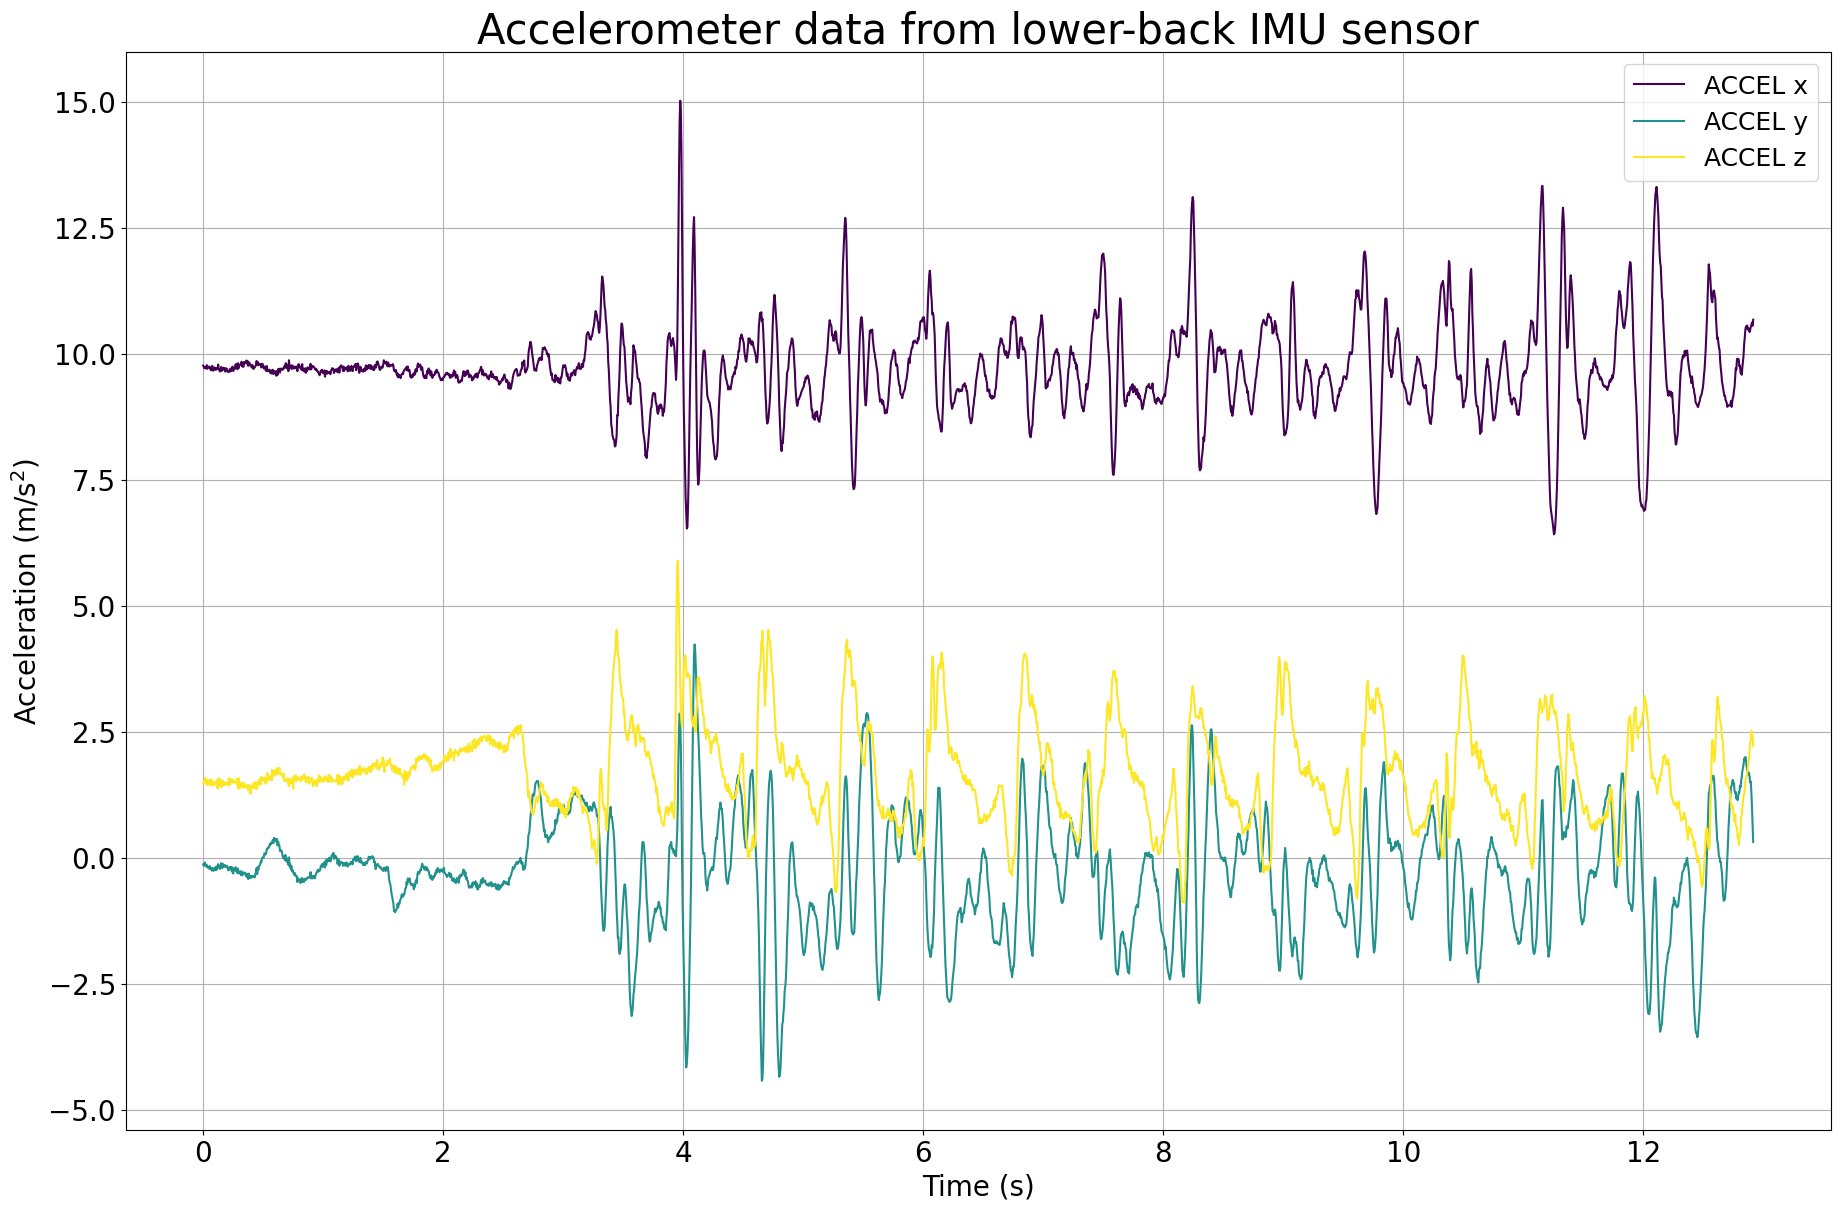

In [2]:
# Calculate the time values
time = np.arange(len(accel_data)) / (sampling_frequency)

# Create a figure with a specified size
plt.figure(figsize=(22, 14))

# Get colors for raw
colors = cfg_colors["raw"]

# A loop is used to plot data for each accelerometer axis, applying different colors from the color map.
for i in range(3):
    plt.plot(
        time,
        accel_data.iloc[:,i],
        color=colors[i],
        label=f"ACCEL {'xyz'[i]}",
    )

# Add labels and legends
plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Acceleration (m/s$^{2}$)", fontsize=20)
plt.legend(fontsize=18)

# Add a title with a specified font size
plt.title(
    "Accelerometer data from lower-back IMU sensor",
    fontsize=30,
)

# Customize tick font sizes
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Display a grid for reference
plt.grid(visible=None, which="both", axis="both")

# Show the plot
plt.show()

In [61]:
print(type(sampling_frequency))

<class 'numpy.int64'>


In [4]:
# Create an instance of the ParaschivIonescuGaitSequenceDetection class
gsd = ParaschivIonescuGaitSequenceDetection()
sampling_frequency = float(sampling_frequency)

# Call the gait sequence detection using gsd.detect to detect gait sequences
gsd.detect(
    accel_data, 
    sampling_frequency, 
    plot_results=False
)

# Gait sequences are stored in gait_sequences_ attribute of gsd
gsd_gait_sequences = gsd.gait_sequences_

print(gsd_gait_sequences)

# Now, use Paraschiv-Ionescu initial contact detection algortihm to find initial contacts within detected gait sequences.
icd = ParaschivIonescuInitialContactDetection()

# Call the initial contact detection using icd.detect
icd.detect(
    accel_data,
    sampling_frequency,
    "pelvis_ACCEL_x",
    gait_sequences=gsd_gait_sequences
)

# Print initial contacts information
print(icd.initial_contacts_)

1 gait sequence(s) detected.
   onset  duration     event_type tracking_system
0  3.125     9.775  gait sequence            None
     onset       event_type  duration tracking_systems
0    3.875  initial contact         0             None
1    4.475  initial contact         0             None
2    5.225  initial contact         0             None
3    5.900  initial contact         0             None
4    6.625  initial contact         0             None
5    7.375  initial contact         0             None
6    8.100  initial contact         0             None
7    8.825  initial contact         0             None
8    9.525  initial contact         0             None
9   10.300  initial contact         0             None
10  11.025  initial contact         0             None
11  11.750  initial contact         0             None
12  12.125  initial contact         0             None
13  12.525  initial contact         0             None


In [63]:
print(mask)

54     True
55     True
56     True
57    False
58    False
59    False
60    False
61    False
62    False
Name: name, dtype: bool


# Our Data

In [ ]:
import pandas as pd
from pathlib import Path

# 1. Get the absolute directory of the current script
script_dir = Path(__file__).resolve().parent

# 2. Build the path to the data folder
# This goes one level up (..), then into the 'data' folder
data_dir = (script_dir / ".." / "data" / "data_set" / "courseA" / "id01").resolve()

# 3. Create a path to a specific file inside that data folder
file_path = data_dir / "xsens.csv"

print(f"Data directory: {data_dir}")
print(f"File path: {file_path}")

data = pd.read_csv(file_path)

sampling_frequency = 60 # 6 recordings in 100 ms -> 60 recordings per second

print(data['acceleration_Pelvis_x'])

#['acceleration_Pelvis_x']

0       -3.558701
1       -3.475930
2       -1.969406
3        0.341094
4       -0.749699
           ...   
41475   -1.472593
41476   -1.700132
41477   -1.207494
41478   -0.109340
41479    0.261701
Name: acceleration_Pelvis_x, Length: 41480, dtype: float64


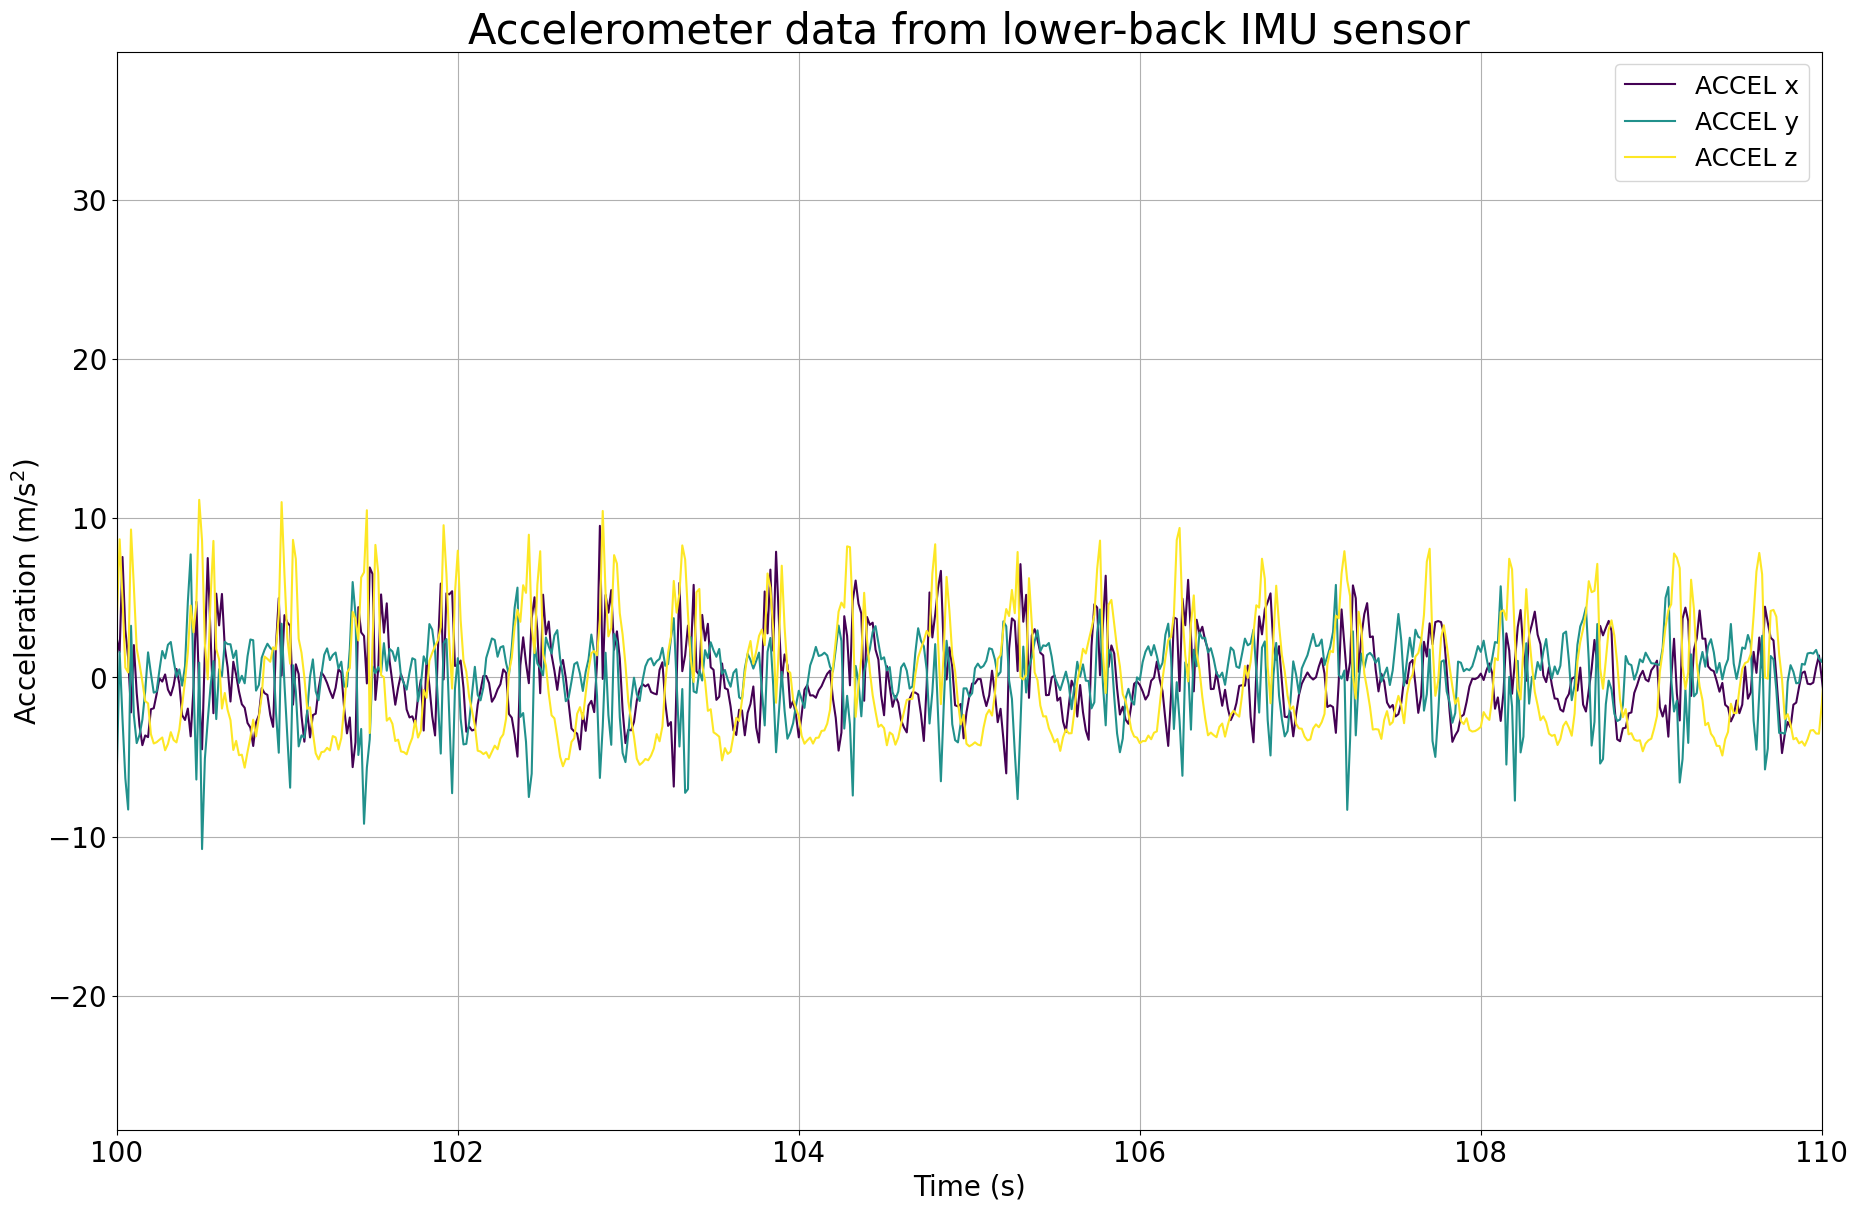

In [6]:
# Calculate the time values
acceleration_data =  data[['acceleration_Pelvis_x', 'acceleration_Pelvis_y', 'acceleration_Pelvis_z']]

time = np.arange(len(acceleration_data)) / (sampling_frequency)

# Create a figure with a specified size
plt.figure(figsize=(22, 14))

# Get colors for raw
colors = cfg_colors["raw"]

# A loop is used to plot data for each accelerometer axis, applying different colors from the color map.
for i in range(3):
    plt.plot(
        time,
        acceleration_data.iloc[:,i],
        color=colors[i],
        label=f"ACCEL {'xyz'[i]}",
    )

# Add labels and legends
plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Acceleration (m/s$^{2}$)", fontsize=20)
plt.legend(fontsize=18)

# Add a title with a specified font size
plt.title(
    "Accelerometer data from lower-back IMU sensor",
    fontsize=30,
)

# Customize tick font sizes
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Display a grid for reference
plt.grid(visible=None, which="both", axis="both")
plt.xlim(100,110)

# Show the plot
plt.show()

In [7]:
print(acceleration_data)



       acceleration_Pelvis_x  acceleration_Pelvis_y  acceleration_Pelvis_z
0                  -3.558701              -1.303026              -0.356919
1                  -3.475930               1.365000              -0.573515
2                  -1.969406               4.122670              -0.351516
3                   0.341094               2.759020               0.293642
4                  -0.749699               0.927965              -0.287982
...                      ...                    ...                    ...
41475              -1.472593              -0.115748               0.547996
41476              -1.700132               0.517141               1.724303
41477              -1.207494               0.554207               2.102795
41478              -0.109340              -0.100649               1.880223
41479               0.261701              -1.085520               1.376982

[41480 rows x 3 columns]


2 gait sequence(s) detected.


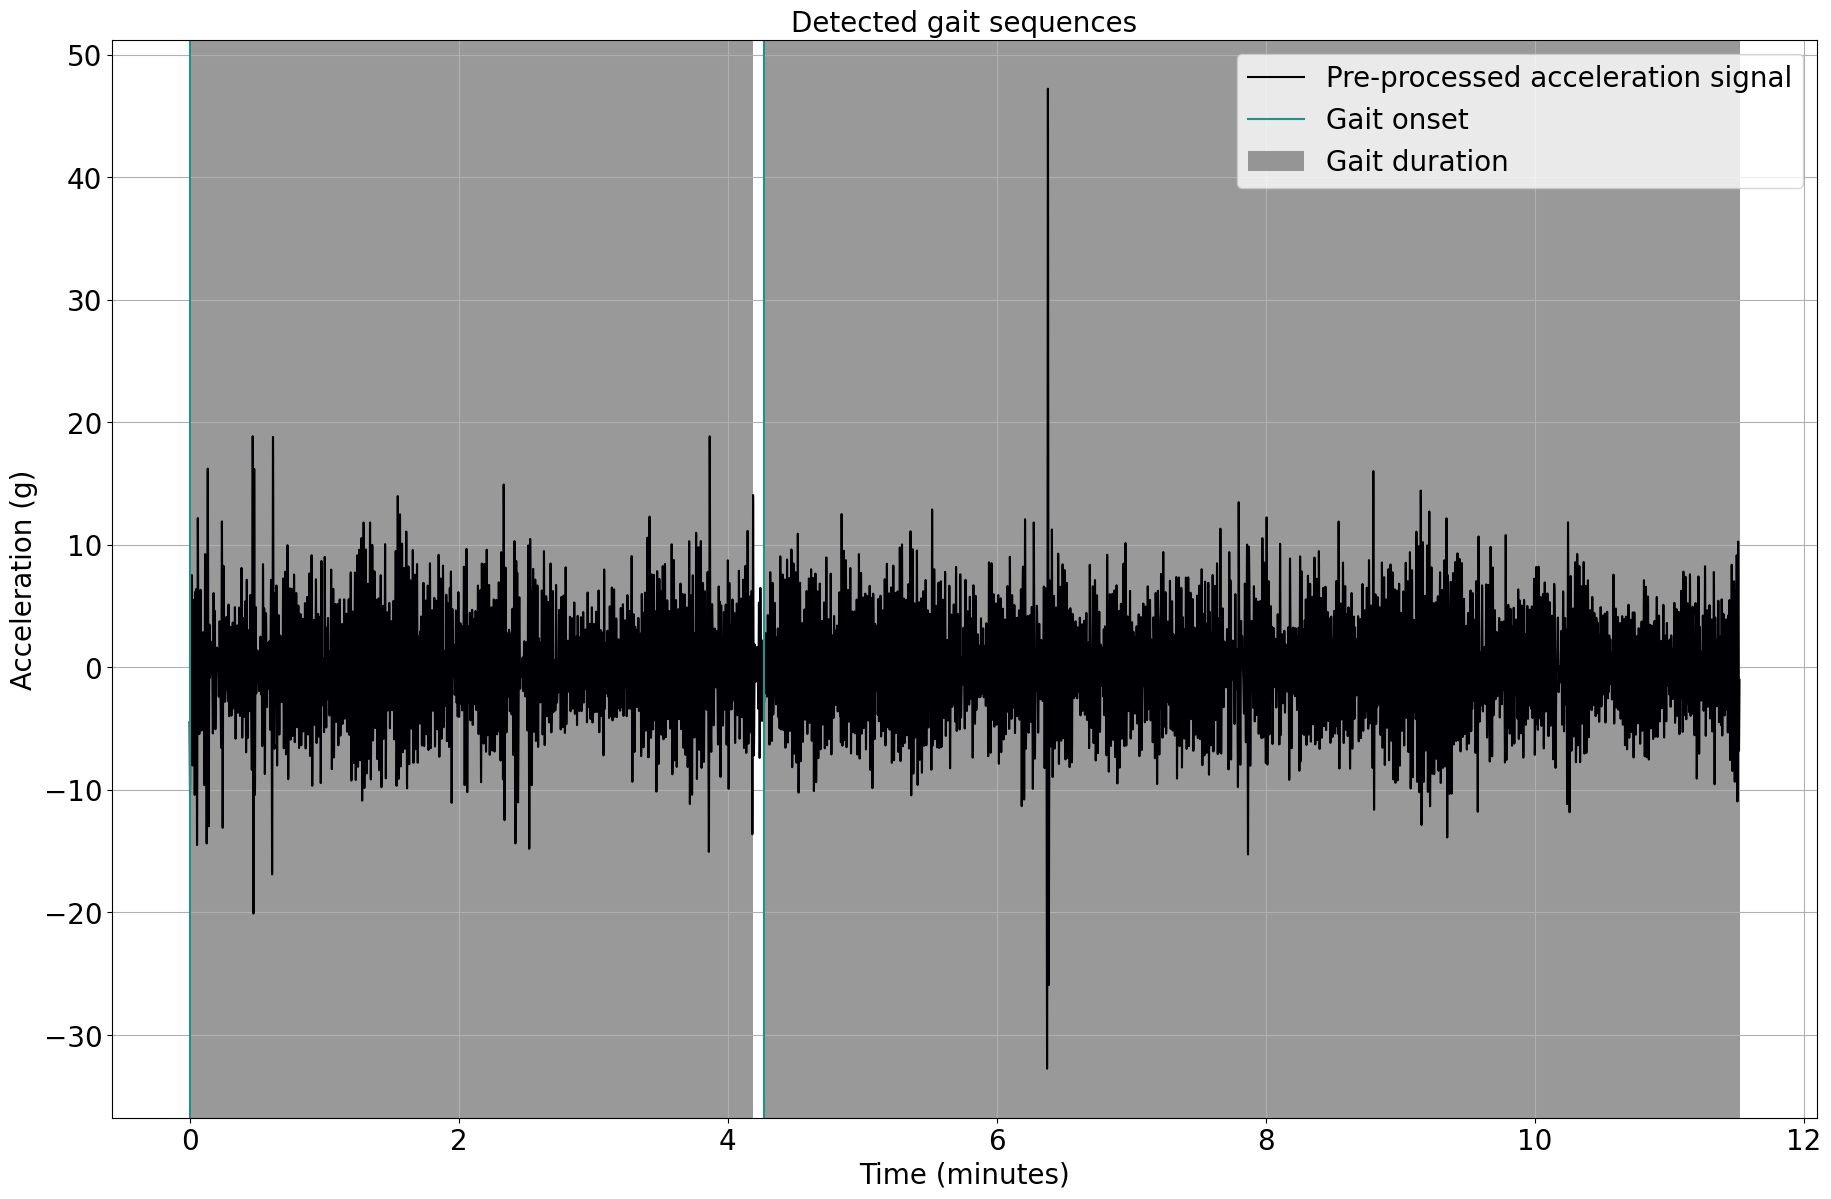

   onset  duration     event_type tracking_system
0    0.0   251.350  gait sequence            None
1  256.3   435.025  gait sequence            None
        onset       event_type  duration tracking_systems
0       0.425  initial contact         0             None
1       0.950  initial contact         0             None
2       1.475  initial contact         0             None
3       1.950  initial contact         0             None
4       2.425  initial contact         0             None
...       ...              ...       ...              ...
1399  688.300  initial contact         0             None
1400  688.825  initial contact         0             None
1401  689.375  initial contact         0             None
1402  689.925  initial contact         0             None
1403  690.550  initial contact         0             None

[1404 rows x 4 columns]


In [ ]:
# Create an instance of the ParaschivIonescuGaitSequenceDetection class
gsd = ParaschivIonescuGaitSequenceDetection()

# Call the gait sequence detection using gsd.detect to detect gait sequences
gsd = gsd.detect(
    acceleration_data, 
    sampling_frequency, 
    True
)

# Gait sequences are stored in gait_sequences_ attribute of gsd
gait_sequences = gsd.gait_sequences_

print(gait_sequences)

# Now, use Paraschiv-Ionescu initial contact detection algortihm to find initial contacts within detected gait sequences.
icd = ParaschivIonescuInitialContactDetection()

# Call the initial contact detection using icd.detect
icd = icd.detect(
    acceleration_data,
    sampling_frequency,
    "acceleration_Pelvis_z"
)

# Print initial contacts information
print(icd.initial_contacts_)

First Gait Sequence: onset                        0.0
duration                  251.35
event_type         gait sequence
tracking_system             None
Name: 0, dtype: object


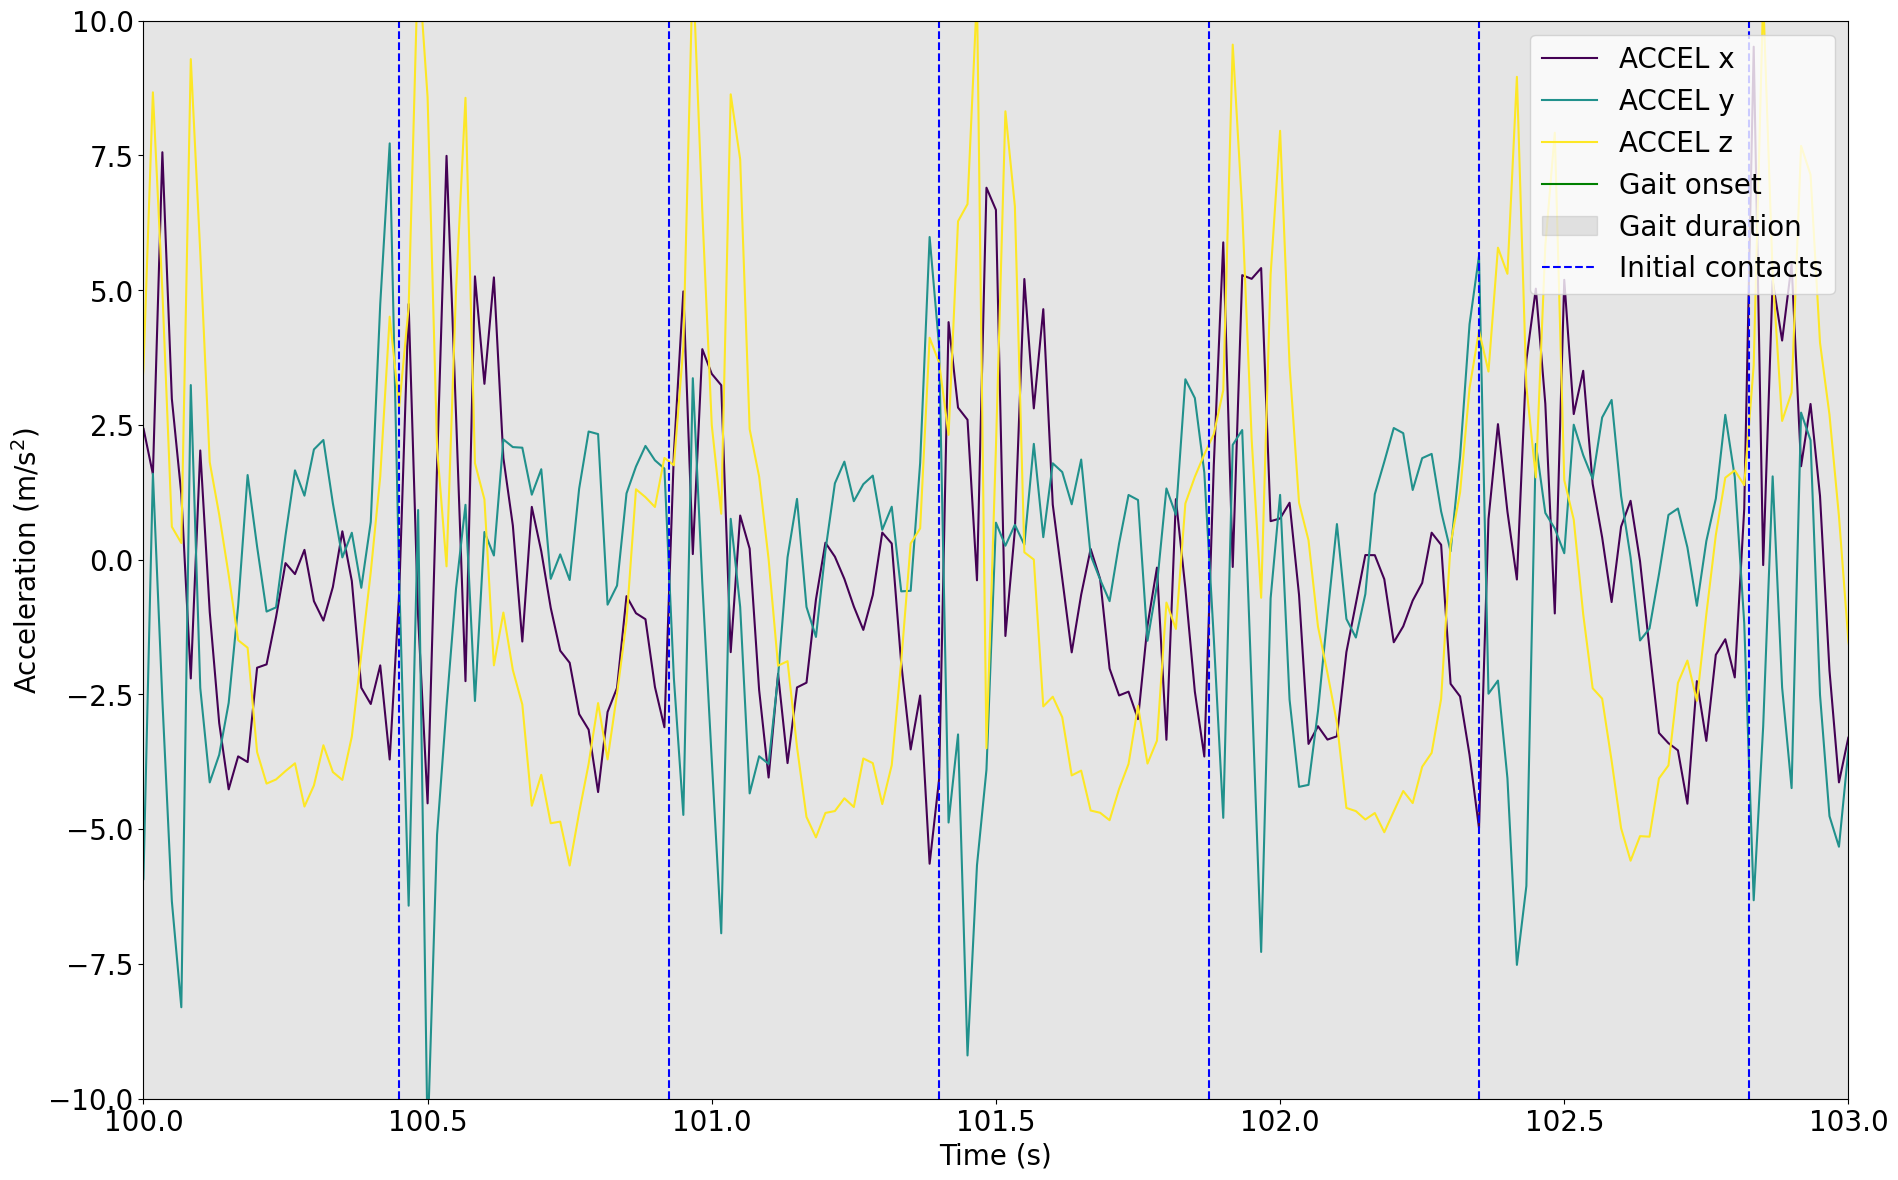

In [15]:
# Access the first detected gait sequence
first_gait_sequence = gsd.gait_sequences_[gsd.gait_sequences_["event_type"] == "gait sequence"].iloc[0]

# Print information about the first gait sequence
print("First Gait Sequence:", first_gait_sequence)

# Print information about initial contacts within the first gait sequence
ic_within_gait = icd.initial_contacts_[
    icd.initial_contacts_["onset"].between(
        first_gait_sequence["onset"],
        first_gait_sequence["onset"] + first_gait_sequence["duration"],
    )
]

# Plot the raw data from the lower back
fig, ax = plt.subplots(figsize=(22, 14))

# Plot raw acceleration data
for i in range(3):
    ax.plot(
        time,
        acceleration_data.iloc[:,i],
        color=colors[i],
        label=f"ACCEL {'xyz'[i]}",
    )

# Plot the first element of gait sequences
plt.axvline(first_gait_sequence["onset"], color="g", label="Gait onset")
ax.axvspan(
    first_gait_sequence["onset"],
    first_gait_sequence["onset"] + first_gait_sequence["duration"],
    alpha=0.2,
    color="gray",
    label="Gait duration",
)

# Plot the initial contacts within the first gait sequence
for ic_time in ic_within_gait["onset"]:
    ax.axvline(ic_time, color="blue", linestyle="--")

# Customize plot
start_limit = first_gait_sequence["onset"] - 1
end_limit = first_gait_sequence["onset"] + first_gait_sequence["duration"] + 1
ax.set_xlim(start_limit, end_limit)
ax.set_xlabel("Time (s)", fontsize=20)
ax.set_ylabel("Acceleration (m/s$^{2}$)", fontsize=20)
ax.set_xlim(100,103)
ax.set_ylim(-10,10)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.legend(
    ["ACCEL x", "ACCEL y", "ACCEL z", "Gait onset", "Gait duration", "Initial contacts"],
    fontsize=20,
    loc="upper right",
)
plt.show()